In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

print("=" * 60)
print("STUDENT PERFORMANCE PREDICTION SYSTEM")
print("DAY 16: MACHINE LEARNING PERFORMANCE PREDICTION")
print("=" * 60)

print("Libraries imported successfully!")

STUDENT PERFORMANCE PREDICTION SYSTEM
DAY 16: MACHINE LEARNING PERFORMANCE PREDICTION
Libraries imported successfully!


In [5]:
students = {
    "Student_ID": [
        "ST301", "ST302", "ST303", "ST304", "ST305",
        "ST306", "ST307", "ST308", "ST309", "ST310",
        "ST311", "ST312", "ST313", "ST314", "ST315"
    ],
    "Study_Hours": [
        1, 2, 3, 4, 5, 6, 7, 8, 2, 4, 6, 9, 3, 7, 5
    ],
    "Attendance": [
        45, 55, 60, 65, 75, 80, 85, 95, 50, 70, 88, 98, 62, 90, 78
    ],
    "Previous_Marks": [
        35, 42, 48, 55, 60, 68, 75, 88, 40, 58, 72, 92, 50, 82, 65
    ],
    "Final_Marks": [
        38, 40, 50, 53, 65, 70, 78, 94, 43, 60, 75, 96, 48, 85, 68
    ]
}

df = pd.DataFrame(students)

print("STUDENT TRAINING DATASET")
print("=" * 65)
print(df.to_string(index=False))

print("\nTotal Students:", len(df))
print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())


STUDENT TRAINING DATASET
Student_ID  Study_Hours  Attendance  Previous_Marks  Final_Marks
     ST301            1          45              35           38
     ST302            2          55              42           40
     ST303            3          60              48           50
     ST304            4          65              55           53
     ST305            5          75              60           65
     ST306            6          80              68           70
     ST307            7          85              75           78
     ST308            8          95              88           94
     ST309            2          50              40           43
     ST310            4          70              58           60
     ST311            6          88              72           75
     ST312            9          98              92           96
     ST313            3          62              50           48
     ST314            7          90              82           85


In [7]:
# Select input features
X = df[
    ["Study_Hours", "Attendance", "Previous_Marks"]
]

# Select target variable
y = df["Final_Marks"]

print("=" * 60)
print("MACHINE LEARNING DATA PREPARATION")
print("=" * 60)

print("\nInput Features (X):")
print(X.head())

print("\nTarget Values (y):")
print(y.head())

print("\nInput Data Shape:", X.shape)
print("Target Data Shape:", y.shape)

print("\nFeatures prepared successfully!")


MACHINE LEARNING DATA PREPARATION

Input Features (X):
   Study_Hours  Attendance  Previous_Marks
0            1          45              35
1            2          55              42
2            3          60              48
3            4          65              55
4            5          75              60

Target Values (y):
0    38
1    40
2    50
3    53
4    65
Name: Final_Marks, dtype: int64

Input Data Shape: (15, 3)
Target Data Shape: (15,)

Features prepared successfully!


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("=" * 60)
print("TRAINING AND TESTING DATA SPLIT")
print("=" * 60)

print("Total Records:", len(X))
print("Training Records:", len(X_train))
print("Testing Records:", len(X_test))

print("\nTraining Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("\nTraining Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

print("\nDataset split completed successfully!")

TRAINING AND TESTING DATA SPLIT
Total Records: 15
Training Records: 12
Testing Records: 3

Training Features Shape: (12, 3)
Testing Features Shape: (3, 3)

Training Target Shape: (12,)
Testing Target Shape: (3,)

Dataset split completed successfully!


In [12]:
# Create the Linear Regression model
model = LinearRegression()

# Train the model using training data
model.fit(X_train, y_train)

print("=" * 60)
print("LINEAR REGRESSION MODEL TRAINING")
print("=" * 60)

print("Model trained successfully!")

print("\nModel Intercept:", round(model.intercept_, 2))

print("\nFeature Coefficients:")
for feature, coefficient in zip(X.columns, model.coef_):
    print(f"{feature}: {coefficient:.2f}")

print("\nTraining Records Used:", len(X_train))


LINEAR REGRESSION MODEL TRAINING
Model trained successfully!

Model Intercept: 1.02

Feature Coefficients:
Study_Hours: 1.95
Attendance: 0.05
Previous_Marks: 0.81

Training Records Used: 12


In [14]:
# Predict marks using the trained model
y_pred = model.predict(X_test)

# Compare actual and predicted marks
prediction_results = pd.DataFrame({
    "Actual_Marks": y_test.values,
    "Predicted_Marks": np.round(y_pred, 2)
})

prediction_results["Prediction_Difference"] = (
    prediction_results["Actual_Marks"]
    - prediction_results["Predicted_Marks"]
).round(2)

print("=" * 65)
print("STUDENT FINAL MARKS PREDICTION")
print("=" * 65)

print(prediction_results.to_string(index=False))

print("\nPredictions Generated:", len(y_pred))
print("Prediction completed successfully!")

STUDENT FINAL MARKS PREDICTION
 Actual_Marks  Predicted_Marks  Prediction_Difference
           60            58.99                   1.01
           96            97.51                  -1.51
           38            33.39                   4.61

Predictions Generated: 3
Prediction completed successfully!


In [16]:
# Calculate model evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=" * 60)
print("MODEL PERFORMANCE EVALUATION")
print("=" * 60)

print(f"Mean Absolute Error (MAE): {mae:.2f} marks")
print(f"R² Score: {r2:.3f}")

print("\nEVALUATION SUMMARY")
print("-" * 60)

print(
    f"On average, predictions differ from actual marks "
    f"by about {mae:.2f} marks on this test sample."
)

if r2 >= 0.7:
    print("R² indicates a relatively strong fit on this test sample.")
elif r2 >= 0.3:
    print("R² indicates a moderate fit on this test sample.")
else:
    print("R² indicates a weak fit on this test sample.")

print("\nEvaluation completed successfully!")

MODEL PERFORMANCE EVALUATION
Mean Absolute Error (MAE): 2.38 marks
R² Score: 0.986

EVALUATION SUMMARY
------------------------------------------------------------
On average, predictions differ from actual marks by about 2.38 marks on this test sample.
R² indicates a relatively strong fit on this test sample.

Evaluation completed successfully!


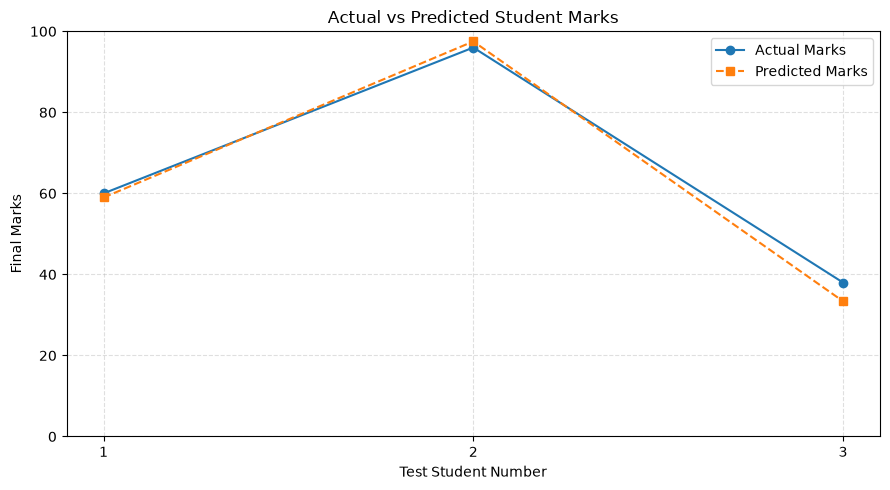

Actual vs Predicted visualization completed!


In [18]:
plt.figure(figsize=(9, 5))

student_numbers = range(1, len(y_test) + 1)

plt.plot(
    student_numbers,
    y_test.values,
    marker="o",
    label="Actual Marks"
)

plt.plot(
    student_numbers,
    y_pred,
    marker="s",
    linestyle="--",
    label="Predicted Marks"
)

plt.title("Actual vs Predicted Student Marks")
plt.xlabel("Test Student Number")
plt.ylabel("Final Marks")
plt.xticks(list(student_numbers))
plt.ylim(0, 100)

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

print("Actual vs Predicted visualization completed!")

In [20]:
# Example data for a new student
new_student = pd.DataFrame({
    "Study_Hours": [5],
    "Attendance": [80],
    "Previous_Marks": [70]
})

# Predict final marks
predicted_marks = model.predict(new_student)[0]

# Keep the prediction within the marks scale
predicted_marks = np.clip(predicted_marks, 0, 100)

print("=" * 60)
print("NEW STUDENT PERFORMANCE PREDICTION")
print("=" * 60)

print("Study Hours:", new_student.loc[0, "Study_Hours"])
print("Attendance:", new_student.loc[0, "Attendance"], "%")
print("Previous Marks:", new_student.loc[0, "Previous_Marks"])

print("\nEstimated Final Marks:", round(predicted_marks, 2), "/ 100")

print("\nPrediction generated successfully!")

NEW STUDENT PERFORMANCE PREDICTION
Study Hours: 5
Attendance: 80 %
Previous Marks: 70

Estimated Final Marks: 71.11 / 100

Prediction generated successfully!


In [22]:
import os

# Create the output folder if needed
os.makedirs("Data", exist_ok=True)

# Prepare prediction report
prediction_report = X_test.copy()

prediction_report["Actual_Marks"] = y_test
prediction_report["Predicted_Marks"] = np.round(y_pred, 2)

prediction_report["Prediction_Difference"] = (
    prediction_report["Actual_Marks"]
    - prediction_report["Predicted_Marks"]
).round(2)

# Export report
output_file = os.path.join(
    "Data",
    "day16_ml_prediction_report.csv"
)

prediction_report.to_csv(output_file, index=True)

print("=" * 60)
print("ML PREDICTION REPORT EXPORTED")
print("=" * 60)

print("Saved Location:", os.path.abspath(output_file))
print("Records Exported:", len(prediction_report))

print("\nReport Preview:")
print(prediction_report.to_string())

ML PREDICTION REPORT EXPORTED
Saved Location: c:\Internship_project\Data\Data\day16_ml_prediction_report.csv
Records Exported: 3

Report Preview:
    Study_Hours  Attendance  Previous_Marks  Actual_Marks  Predicted_Marks  Prediction_Difference
9             4          70              58            60            58.99                   1.01
11            9          98              92            96            97.51                  -1.51
0             1          45              35            38            33.39                   4.61


In [23]:
print("=" * 65)
print("STUDENT PERFORMANCE PREDICTION SYSTEM")
print("DAY 16: MACHINE LEARNING PERFORMANCE PREDICTION")
print("=" * 65)

print("\nPROJECT SUMMARY")
print("-" * 65)
print("Total Dataset Records:", len(df))
print("Training Records:", len(X_train))
print("Testing Records:", len(X_test))
print("Algorithm Used: Linear Regression")

print("\nMODEL EVALUATION")
print("-" * 65)
print(f"Mean Absolute Error: {mae:.2f} marks")
print(f"R² Score: {r2:.3f}")

print("\nFEATURES COMPLETED")
print("-" * 65)

features = [
    "Student dataset creation",
    "Feature and target preparation",
    "Training and testing split",
    "Linear Regression model training",
    "Student marks prediction",
    "Model performance evaluation",
    "Actual vs predicted visualization",
    "New student prediction",
    "CSV prediction report export"
]

for i, feature in enumerate(features, start=1):
    print(f"{i}. {feature}")

print("\nOUTPUT REPORT")
print("-" * 65)
print("day16_ml_prediction_report.csv")

print("\nDay 16 implementation completed!")
print("=" * 65)

STUDENT PERFORMANCE PREDICTION SYSTEM
DAY 16: MACHINE LEARNING PERFORMANCE PREDICTION

PROJECT SUMMARY
-----------------------------------------------------------------
Total Dataset Records: 15
Training Records: 12
Testing Records: 3
Algorithm Used: Linear Regression

MODEL EVALUATION
-----------------------------------------------------------------
Mean Absolute Error: 2.38 marks
R² Score: 0.986

FEATURES COMPLETED
-----------------------------------------------------------------
1. Student dataset creation
2. Feature and target preparation
3. Training and testing split
4. Linear Regression model training
5. Student marks prediction
6. Model performance evaluation
7. Actual vs predicted visualization
8. New student prediction
9. CSV prediction report export

OUTPUT REPORT
-----------------------------------------------------------------
day16_ml_prediction_report.csv

Day 16 implementation completed!
